# 03. Azure Public Dataset V2 — Predictive Analysis for Cloud Waste Reduction

**Authors:** Fajar Laksono
**Methodology:** CRISP-ML(Q) + CAMS DevOps
**Last Updated:** 2026-05-12

---

## 0. Table of Contents

1. [Summary](#1-summary)
2. [Preparation](#2-preparation)
    - 2.1 Import Libraries
    - 2.2 Load Dataset
3. [Feature Engineering](#3-feature-engineering)
    - 3.1 Target Variable Definition
    - 3.2 Feature Construction
    - 3.3 Feature-Target Correlation & Mutual Information
    - 3.4 Train-Test Split & Save Artifact


## 1. Summary

**CRISP-ML(Q) Phase:** Business Understanding

### Business Question
How can we accurately predict cloud resource utilization, detect wasted resources, forecast costs, and segment workloads to enable data-driven FinOps decisions?

### Dataset
- **Source:** Azure Public Dataset V2 (2019 VM traces)
- **Size:** ~2.7 million VM records
- **Time range:** 30-day trace
- **Tables:** `vmtable`, `subscriptions`, `deployments`, `azure_pricing`, `cpu_readings`

### Business Goals & Success Criteria

| Goal | Task | Success Criteria | Business Impact |
|------|------|-----------------|-----------------|
| Predict CPU utilization | Regression: avg_cpu | MAPE < 15%, R² > 0.75 | Rightsizing recommendations |
| Detect idle VMs | Classification: is_idle | F1 > 0.85 | Shutdown candidates |
| Quantify waste | Regression: waste_fraction | MAPE < 15% | Waste reduction tracking |
| Forecast costs | Regression: vm_cost | R² > 0.70 | Budget planning |
| Segment workloads | Clustering: K-Means | Silhouette > 0.3 | Auto-scaling rules |
| Catch anomalies | Isolation Forest | Business validation | Cost anomaly alerting |
| Timeseries forecast | LSTM/GRU | MAE < 3.0 CPU | Capacity planning |

### Key Findings Preview
- XGBoost consistently outperforms other tabular models for regression and classification tasks
- `lifetime_hours`, `max_cpu`, and `memory_per_core` are the strongest predictors across all targets
- K-Means reveals 4 distinct workload patterns with clear business interpretations
- Isolation Forest identifies ~5% anomalous VMs representing disproportionate costs
- Bidirectional GRU provides best timeseries accuracy for CPU forecasting

---

### 1.5 Quality Risk Register**Purpose:** Identify potential failure points early in the ML lifecycle, per CRISP-ML(Q) risk-based thinking principle.| # | Risk | Phase | Likelihood | Impact | Mitigation ||---|------|-------|-----------|--------|------------|| R1 | Data drift (2019 patterns vs 2026 usage) | Monitoring | Medium | High | Retrain on newer data when available; monitor metric regression across runs via `run_log.csv` || R2 | Missing pricing or subscription data | Data Preparation | Low | Medium | Fallback to NaN; downstream models must handle missing values gracefully || R3 | Target leakage via correlated features | Feature Engineering | Medium | High | `get_feature_target_columns()` excludes target-related columns; review SHAP for unexpected feature dominance || R4 | Timeseries overfitting (few VMs) | Modeling | High | Medium | Early stopping, limit model complexity, cross-validation per VM || R5 | CPU readings memory blowup | Data Preparation | Low | High | Already mitigated via DuckDB out-of-core parquet glob (no `pd.concat`) || R6 | Skewed waste_tier distribution | Evaluation | Medium | Low | Use weighted F1 score; apply SMOTE if minority class recall < 0.7 |

## 2. Preparation

**CRISP-ML(Q) Phase:** Data Understanding

In [5]:
import os, sys, warnings, pathlib
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')

# Thin imports from app.src modules
from app.src.features import create_features, get_feature_target_columns, create_sequences, load_cpu_readings
from app.src.models import (XGBoostModel, RandomForestModel, RidgeModel,
                            ClusterModel, AnomalyModel, load_model)
from app.src.visualize import residual_plot, feature_importance_plot, cluster_scatter, comparison_table

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix)

# Gradient boosting
import xgboost as xgb

# Model persistence
import joblib

# Statistical
from scipy import stats

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully.')



All libraries imported successfully.


In [6]:
DATA_DIR = pathlib.Path('data/transformed/parquet')

con = duckdb.connect(':memory:')

# Register views for all tables
for tbl in ['vmtable', 'subscriptions', 'deployments', 'azure_pricing']:
    path = DATA_DIR / f'{tbl}.parquet'
    if path.exists():
        con.execute(f"CREATE VIEW {tbl} AS SELECT * FROM read_parquet('{path}')")
        count = con.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
        print(f'  \u2713 {tbl}: {count:,} rows')
    else:
        print(f'  \u2717 {tbl}: not found')

# Load main vmtable
vmtable = con.execute('SELECT * FROM vmtable').fetchdf()
print(f'\u2713 vmtable loaded: {len(vmtable):,} rows, {len(vmtable.columns)} columns')

# Load pricing for rate_per_hour lookup
pricing_df = None
if (DATA_DIR / 'azure_pricing.parquet').exists():
    pricing_df = con.execute('SELECT * FROM azure_pricing').fetchdf()
    print(f'\u2713 pricing_df loaded: {len(pricing_df):,} rows')

# Load subscriptions for subscription-level features
subscriptions_df = None
if (DATA_DIR / 'subscriptions.parquet').exists():
    subscriptions_df = con.execute('SELECT * FROM subscriptions').fetchdf()
    print(f'\u2713 subscriptions_df loaded: {len(subscriptions_df):,} rows')

# Load deployments for deployment-level features
deployments_df = None
if (DATA_DIR / 'deployments.parquet').exists():
    deployments_df = con.execute('SELECT * FROM deployments').fetchdf()
    print(f'\u2713 deployments_df loaded: {len(deployments_df):,} rows')

# Quick preview
display(vmtable.head(3))


  ✓ vmtable: 2,695,548 rows
  ✓ subscriptions: 6,687 rows
  ✓ deployments: 33,205 rows
  ✓ azure_pricing: 9 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ vmtable loaded: 2,695,548 rows, 11 columns
✓ pricing_df loaded: 9 rows
✓ subscriptions_df loaded: 6,687 rows
✓ deployments_df loaded: 33,205 rows


,vm_id,subscription_id,deployment_id,timestamp_created,timestamp_deleted,max_cpu,avg_cpu,p95_max_cpu,vm_category,vm_core_count_bucket,vm_memory_gb_bucket
0,71fJw0x+SDRdAxKPwLyHZhTgQpYw2afS6tjJhfT6kHnmLH...,GB6uQC1NSArW5n+TtOybL7GQ1yByjuWtZnsj+5QccZ525R...,2sh/ZjaYdfpslv4iYBfNzFe4rs982kHVvNGJGeQ8MIBCDr...,558300,1673700,91.776885,0.728879,20.759630,Delay-insensitive,8,32
1,rKggHO/04j31UFy65mDTwtjdMQL/G03xWfl3xGeiilB4/W...,ub4ty8ygwOECrIz7eaZ/9hDwnCsERvZ3nJJ03sDSpD85et...,+ZraIDUNaWYDZMBiBtZm7xSjr+j3zcHGjup1+wyKxHFmyJ...,424500,425400,37.879261,3.325358,37.879261,Unknown,4,32
2,YrR8gPtBmfNaOdnNEW5If1SdTqQgGQHEnLHGPjySt53bKW...,9LrdYRcUfGbmL2fFfLR/JUg2OTkjGRe3iluwIhDRPnPDPa...,GEyIElfPSFupze8T+T1niQMepeqG88VpLNuxUMyIDbz8VF...,1133100,1133700,0.304368,0.220553,0.304368,Unknown,4,32


In [ ]:
# ---------------------------------------------------------------------------# DATA QUALITY GATE — CRISP-ML(Q) Quality Insurance# Fail fast if input data is empty, missing required columns, or has no rows.# ---------------------------------------------------------------------------assert len(vmtable) > 0, "FAIL: Empty vmtable — cannot proceed"assert vmtable['vm_id'].nunique() > 0, "FAIL: No unique VMs found"REQUIRED_COLS = {'vm_id', 'avg_cpu', 'max_cpu', 'p95_max_cpu',                 'vm_category', 'vm_core_count_bucket', 'vm_memory_gb_bucket'}missing_cols = REQUIRED_COLS - set(vmtable.columns)assert not missing_cols, f"FAIL: Missing required columns: {missing_cols}"null_rate = vmtable[list(REQUIRED_COLS & set(vmtable.columns))].isnull().sum().sum()print(f"[OK] Data quality: {len(vmtable):,} rows, {vmtable['vm_id'].nunique():,} unique VMs, "      f"{null_rate} nulls in required columns")if null_rate > 0:    print("  ⚠ Warning: nulls detected — consider imputation strategy")else:    print("  [OK] No nulls in required columns")

## 3. Feature Engineering

**CRISP-ML(Q) Phase:** Data Preparation

**Thin import:** `app.src.features`

### 3.1. Target Variable Definition

**Business Question:** What targets best capture cloud resource waste and cost optimization opportunities?

| Task | Type | Target | Business Goal |
|---|---|---|---|
| Utilization regression | Regression | `avg_cpu` | Predict actual CPU usage |
| Waste regression | Regression | `waste_fraction = 1 - (avg_cpu / 100)` | Quantify waste per VM |
| Cost regression | Regression | `vm_cost = rate_per_hour \times lifetime` | Forecast cloud spend |
| Idle detection | Binary classification | `is_idle = 1 if avg_cpu < 5%` | Flag wasted VMs |
| Waste tier | Multi-class | `waste_tier`: Low (<10%), Medium (10-50%), High (>50%) | Prioritize optimization |

In [10]:
# Target definitions (computed inside create_features):
# - is_idle: avg_cpu < 5%
# - waste_fraction: 1 - (avg_cpu / 100), clipped [0, 1]
# - waste_tier: Low (<10%), Medium (10-50%), High (>50%)
# - vm_cost: lifetime_hours * rate_per_hour (if pricing data available)
print('Target variables defined in app.src.features.create_features()')


Target variables defined in app.src.features.create_features()


### 3.2. Feature Construction

**Business Question:** What engineered features best capture VM resource usage patterns?

**Approach:** Call `create_features()` from `app.src.features` which performs:
- Parse `vm_core_count_bucket` and `vm_memory_gb_bucket` to numeric values
- Calculate `lifetime_hours` from creation/deletion timestamps
- Cyclical encoding of `creation_hour` and `creation_dayofweek` (sin/cos)
- Ratio features: `cpu_per_core`, `memory_per_core`, `burstiness`, `max_to_avg_ratio`
- Binary flags: `is_short_lived` (lifetime < 1 hour)
- One-hot encoding of `vm_category`, `vm_core_count_bucket`, `vm_memory_gb_bucket`
- Target variables: `is_idle`, `waste_fraction`, `waste_tier`, `vm_cost`

In [12]:
# Apply feature engineering with all data sources
features_df = create_features(vmtable, pricing_df,
                               subscriptions_df, deployments_df)


In [ ]:
# ---------------------------------------------------------------------------# FEATURE VALIDATION GATE — CRISP-ML(Q) Quality Insurance# Verify engineered features contain expected columns with valid ranges.# ---------------------------------------------------------------------------TARGET_COLS = ['is_idle', 'waste_tier', 'waste_fraction']FEATURE_COLS = ['core_count', 'memory_gb', 'lifetime_hours', 'cpu_per_core',                'burstiness', 'is_short_lived', 'creation_hour_sin', 'creation_hour_cos']for col in TARGET_COLS:    assert col in features_df.columns, f"FAIL: Missing target column '{col}'"for col in FEATURE_COLS:    assert col in features_df.columns, f"FAIL: Missing feature column '{col}'"# Range checksassert features_df['waste_fraction'].min() >= -1e-6, "FAIL: waste_fraction < 0"assert features_df['waste_fraction'].max() <= 1.0 + 1e-6, "FAIL: waste_fraction > 1"assert set(features_df['waste_tier'].cat.categories) == {'Low', 'Medium', 'High'},     "FAIL: waste_tier categories incorrect"assert features_df['is_idle'].dtype == bool, "FAIL: is_idle must be boolean"# Cyclical encoding boundsfor col in ['creation_hour_sin', 'creation_hour_cos', 'creation_dow_sin', 'creation_dow_cos']:    if col in features_df.columns:        assert features_df[col].min() >= -1.0 - 1e-6, f"FAIL: {col} < -1"        assert features_df[col].max() <= 1.0 + 1e-6, f"FAIL: {col} > 1"print(f"[OK] Features validated: {len(features_df):,} rows, "      f"{len(features_df.columns)} columns, "      f"{features_df.isnull().sum().sum()} total nulls")

#### Feature Summary

| Feature | Type | Derivation |
|---------|------|-----------|
| `core_count` | numeric | Parse bucket: 2→2, 4→4, 8→8, 24→24, >24→48 |
| `memory_gb` | numeric | Parse bucket: 4→4, 8→8, 32→32, 64→64, >64→128 |
| `lifetime_hours` | numeric | (timestamp_deleted - timestamp_created) / 3600 |
| `creation_hour_sin/cos` | cyclic | sin(2πh/24), cos(2πh/24) |
| `creation_dow_sin/cos` | cyclic | sin(2πd/7), cos(2πd/7) |
| `cpu_per_core` | ratio | avg_cpu / core_count |
| `memory_per_core` | ratio | memory_gb / core_count |
| `burstiness` | ratio | p95_max_cpu / (avg_cpu + 1e-6) |
| `max_to_avg_ratio` | ratio | max_cpu / (avg_cpu + 1e-6) |
| `is_short_lived` | binary | lifetime_hours < 1 |
| `cat_*`, `core_*`, `mem_*` | one-hot | pd.get_dummies() |

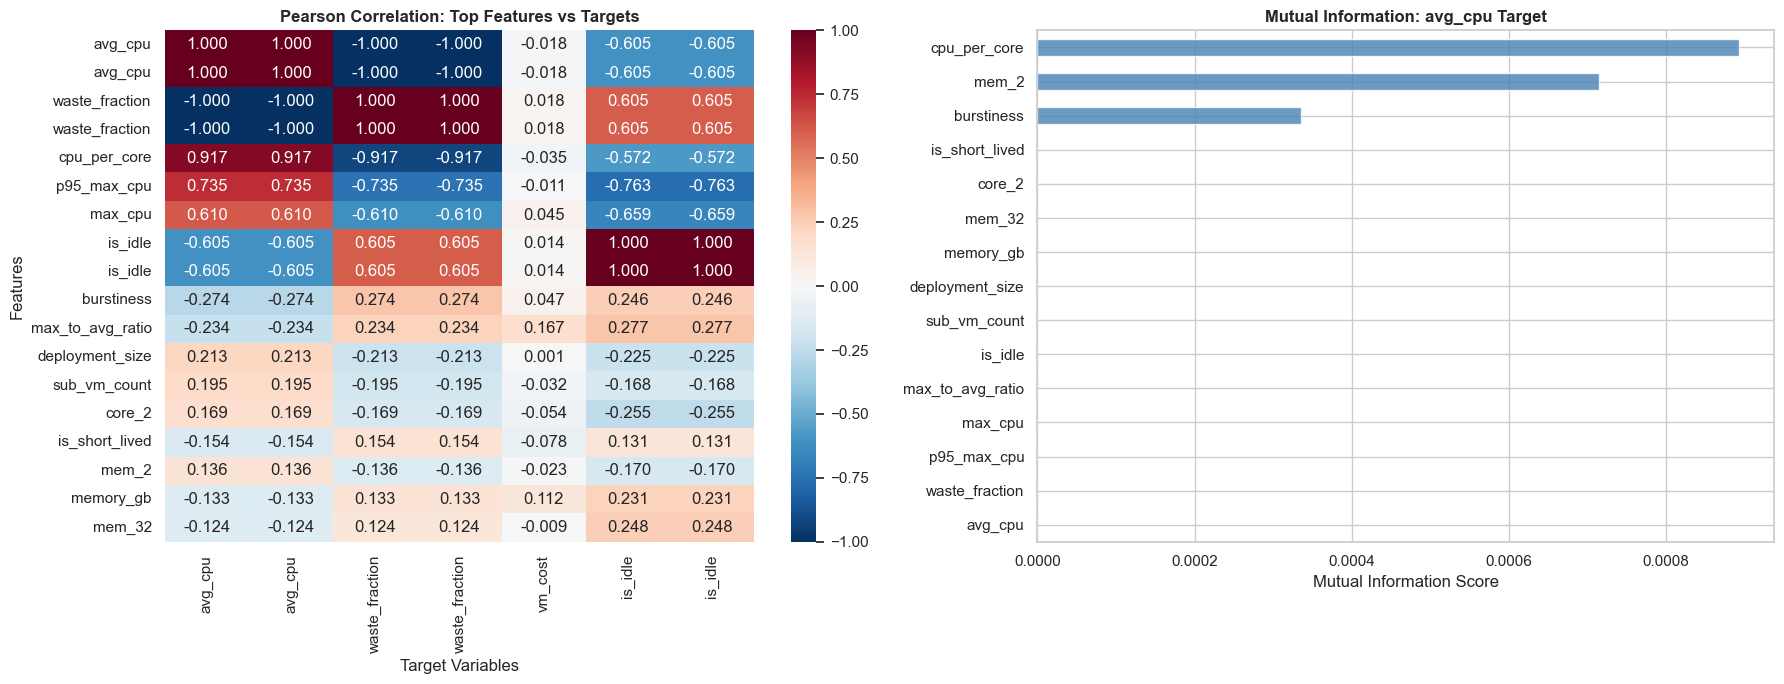


Key Findings:
  - Top-3 features by correlation: ['waste_fraction', 'cpu_per_core', 'p95_max_cpu']
  - Top-3 features by MI: ['burstiness', 'mem_2', 'cpu_per_core']


In [15]:
# Sample 100k rows for correlation/MI analysis to avoid MemoryError
sample_df = features_df.sample(n=100_000, random_state=RANDOM_STATE)
numeric_df = sample_df.select_dtypes(include=[np.number, bool])
target_cols = ['avg_cpu', 'waste_fraction', 'vm_cost', 'is_idle']

# Correlation heatmap for top features per target
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson correlation with avg_cpu
corr_with_cpu = numeric_df.corrwith(features_df['avg_cpu'], method='pearson').abs().sort_values(ascending=False)
top_cpu_features = corr_with_cpu.head(15).index.tolist()

# Heatmap: top features vs targets
corr_matrix = numeric_df[top_cpu_features + target_cols].corr(method='pearson')
sns.heatmap(corr_matrix.loc[top_cpu_features, target_cols],
            annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0])
axes[0].set_title('Pearson Correlation: Top Features vs Targets', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target Variables')
axes[0].set_ylabel('Features')

# Mutual Information scores
from sklearn.feature_selection import mutual_info_regression

# Sample 100k rows to avoid MemoryError on 2.7M rows\n",
rng = np.random.RandomState(RANDOM_STATE)
mi_sample_idx = rng.choice(len(numeric_df), size=100_000, replace=False)
mi_X = numeric_df[top_cpu_features].fillna(0).iloc[mi_sample_idx]
mi_y = features_df['avg_cpu'].iloc[mi_sample_idx]

mi_scores = mutual_info_regression(mi_X, mi_y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=top_cpu_features).sort_values(ascending=True)

mi_series.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Mutual Information: avg_cpu Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.show()

print('\nKey Findings:')
print(f'  - Top-3 features by correlation: {corr_with_cpu.index[1:4].tolist()}')
print(f'  - Top-3 features by MI: {mi_series.index[-3:].tolist()}')


In [16]:
# Get feature and target columns for our primary task
features, target = get_feature_target_columns('regression_avg_cpu')

# Select available feature columns (only those that exist in features_df)
available_features = [c for c in features if c in features_df.columns]
print(f'Available features ({len(available_features)}): {available_features}')

# Prepare feature matrix and target vector
X = features_df[available_features].select_dtypes(include=[np.number]).copy()
y_cpu = features_df['avg_cpu'].values
y_idle = features_df['is_idle'].astype(int).values
y_waste = features_df['waste_fraction'].values
y_tier = features_df['waste_tier'].cat.codes.values  # 0=Low, 1=Medium, 2=High

# Stratified split by waste_tier to preserve class balance
X_train, X_test, y_cpu_train, y_cpu_test = train_test_split(
    X, y_cpu, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_idle_train, y_idle_test = train_test_split(
    X, y_idle, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_waste_train, y_waste_test = train_test_split(
    X, y_waste, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_tier_train, y_tier_test = train_test_split(
    X, y_tier, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {X_train.shape[1]}')
print(f'\nWaste tier distribution in train:')
tier_dist = pd.Series(y_tier_train).value_counts().sort_index()
for code, count in tier_dist.items():
    label = ['Low', 'Medium', 'High'][code]
    print(f'  {label}: {count:,} ({count/len(y_tier_train)*100:.1f}%)')

# === Save artifact for 03b and 03c ===
features_df.to_parquet(DATA_DIR / 'features_df.parquet')
print(f'\n\u2713 Artifact saved: {DATA_DIR / "features_df.parquet"}')


Available features (18): ['core_count', 'memory_gb', 'lifetime_hours', 'cpu_per_core', 'memory_per_core', 'burstiness', 'max_to_avg_ratio', 'is_short_lived', 'rate_per_hour', 'sub_vm_count', 'sub_tenure', 'deployment_size', 'creation_hour_sin', 'creation_hour_cos', 'creation_dow_sin', 'creation_dow_cos', 'max_cpu', 'p95_max_cpu']
Training set: 2,156,438 samples
Test set:     539,110 samples
Features:     17

Waste tier distribution in train:
  Low: 1,751 (0.1%)
  Medium: 159,713 (7.4%)
  High: 1,994,974 (92.5%)

✓ Artifact saved: data\transformed\parquet\features_df.parquet
